# 03 – Preprocessing & Feature Engineering (Hanya Polutan)
**Proyek Capstone – Sistem Prediksi Kualitas Udara & Deteksi Anomali (Aeris)**
**Kelompok Aeris | PENS 2026**
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 2 | 4 Mei – 10 Mei 2026**

## 1. Setup & Load Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)

for folder in ["data/processed", "models", "reports/preprocessing"]:
    os.makedirs(folder, exist_ok=True)

# HANYA POLUTAN (meteorologi tidak tersedia)
POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
METEO = []  # KOSONGKAN

LABELS = {
    "pm25": "PM2.5 (µg/m³)",
    "pm10": "PM10 (µg/m³)",
    "co": "CO (µg/m³)",
    "no2": "NO₂ (µg/m³)",
    "o3": "O₃ (µg/m³)",
}

df = pd.read_csv("data/raw/surabaya_airquality_raw.csv", parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"✅ Data dimuat: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Kolom: {list(df.columns)}")
df.head(3)

✅ Data dimuat: 3,768 baris × 6 kolom
   Kolom: ['time', 'pm25', 'pm10', 'co', 'no2', 'o3']


,time,pm25,pm10,co,no2,o3
0,2026-01-01 00:00:00,100.4,100.6,961.0,79.6,3.0
1,2026-01-01 01:00:00,110.1,110.6,832.0,77.6,3.0
2,2026-01-01 02:00:00,116.9,118.3,657.0,75.2,1.0


## 2. Split Train / Test TERLEBIH DAHULU

In [2]:
SPLIT_RATIO = 0.80
split_idx = int(len(df) * SPLIT_RATIO)
split_date = df.loc[split_idx, "time"]

train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print("=" * 60)
print("2. SPLIT TRAIN / TEST")
print("=" * 60)
print(f"Split date: {split_date}")
print(f"Train: {len(train_raw):,} baris ({train_raw['time'].iloc[0]} → {train_raw['time'].iloc[-1]})")
print(f"Test : {len(test_raw):,} baris ({test_raw['time'].iloc[0]} → {test_raw['time'].iloc[-1]})")

2. SPLIT TRAIN / TEST
Split date: 2026-05-06 14:00:00
Train: 3,014 baris (2026-01-01 00:00:00 → 2026-05-06 13:00:00)
Test : 754 baris (2026-05-06 14:00:00 → 2026-06-06 23:00:00)


## 3. Handle Missing Values

In [3]:
print("=" * 60)
print("3. HANDLE MISSING VALUES")
print("=" * 60)

print("\n[SEBELUM] Missing values pada train:")
mv_before = train_raw[POLUTAN].isnull().sum()
if mv_before.sum() == 0:
    print("  ✅ Tidak ada missing values.")
else:
    print(mv_before[mv_before > 0].to_string())

# Handle TRAIN - hanya polutan
for col in POLUTAN:
    train_raw[col] = train_raw[col].ffill()
    first_valid = train_raw[col].first_valid_index()
    if first_valid is not None:
        train_raw[col] = train_raw[col].fillna(train_raw.loc[first_valid, col])

# Handle TEST
for col in POLUTAN:
    test_raw[col] = test_raw[col].ffill()
    if test_raw[col].isna().any():
        last_train_val = train_raw[col].iloc[-1]
        test_raw[col] = test_raw[col].fillna(last_train_val)

print("\n[SESUDAH] Missing values pada train:")
mv_after_train = train_raw[POLUTAN].isnull().sum()
print(f"  Total NaN train: {mv_after_train.sum()}")
print("\n✅ Missing values handled!")

3. HANDLE MISSING VALUES

[SEBELUM] Missing values pada train:
  ✅ Tidak ada missing values.

[SESUDAH] Missing values pada train:
  Total NaN train: 0

✅ Missing values handled!


## 4. Handle Outliers (Capping 3×IQR)

**Strategi:** Capping dengan batas 3×IQR dari TRAINING SET saja.
- Menggunakan 3×IQR (bukan 1.5×IQR) untuk mempertahankan event anomali nyata
- Nilai negatif di-clip ke 0
- Batas dihitung dari TRAIN, diterapkan ke TRAIN dan TEST

In [4]:
print("=" * 60)
print("4. HANDLE OUTLIERS (Capping 3×IQR dari TRAIN)")
print("=" * 60)

outlier_bounds = {}

for col in POLUTAN:
    # Hitung IQR dari TRAIN SAJA (anti-leakage)
    Q1 = train_raw[col].quantile(0.25)
    Q3 = train_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Batas capping: 3×IQR (lebih longgar dari 1.5×IQR)
    lower = max(0, Q1 - 3 * IQR)   # tidak boleh negatif
    upper = Q3 + 3 * IQR
    
    outlier_bounds[col] = {"lower": lower, "upper": upper}
    
    # Hitung jumlah outlier sebelum capping
    n_out_train = ((train_raw[col] < lower) | (train_raw[col] > upper)).sum()
    n_out_test = ((test_raw[col] < lower) | (test_raw[col] > upper)).sum()
    
    # Terapkan capping ke TRAIN dan TEST
    train_raw[col] = train_raw[col].clip(lower=lower, upper=upper)
    test_raw[col] = test_raw[col].clip(lower=lower, upper=upper)
    
    print(f"{LABELS[col]:<12} | Lower={lower:>10.2f} | Upper={upper:>10.2f} | Capped Train={n_out_train:>4} | Capped Test={n_out_test:>4}")

print("\n✅ Outlier handling selesai!")
print("   - Nilai negatif → di-clip ke 0")
print("   - Batas 3×IQR → mempertahankan event anomali nyata")
print("   - Hanya nilai ekstrem error sensor yang di-cap")

4. HANDLE OUTLIERS (Capping 3×IQR dari TRAIN)
PM2.5 (µg/m³) | Lower=      0.00 | Upper=    118.30 | Capped Train=  18 | Capped Test=   7
PM10 (µg/m³) | Lower=      0.00 | Upper=    119.60 | Capped Train=  20 | Capped Test=   6
CO (µg/m³)   | Lower=      0.00 | Upper=   5487.25 | Capped Train=  20 | Capped Test=   0
NO₂ (µg/m³)  | Lower=      0.00 | Upper=    134.30 | Capped Train=   3 | Capped Test=   0
O₃ (µg/m³)   | Lower=      0.00 | Upper=    333.00 | Capped Train=   0 | Capped Test=   0

✅ Outlier handling selesai!
   - Nilai negatif → di-clip ke 0
   - Batas 3×IQR → mempertahankan event anomali nyata
   - Hanya nilai ekstrem error sensor yang di-cap


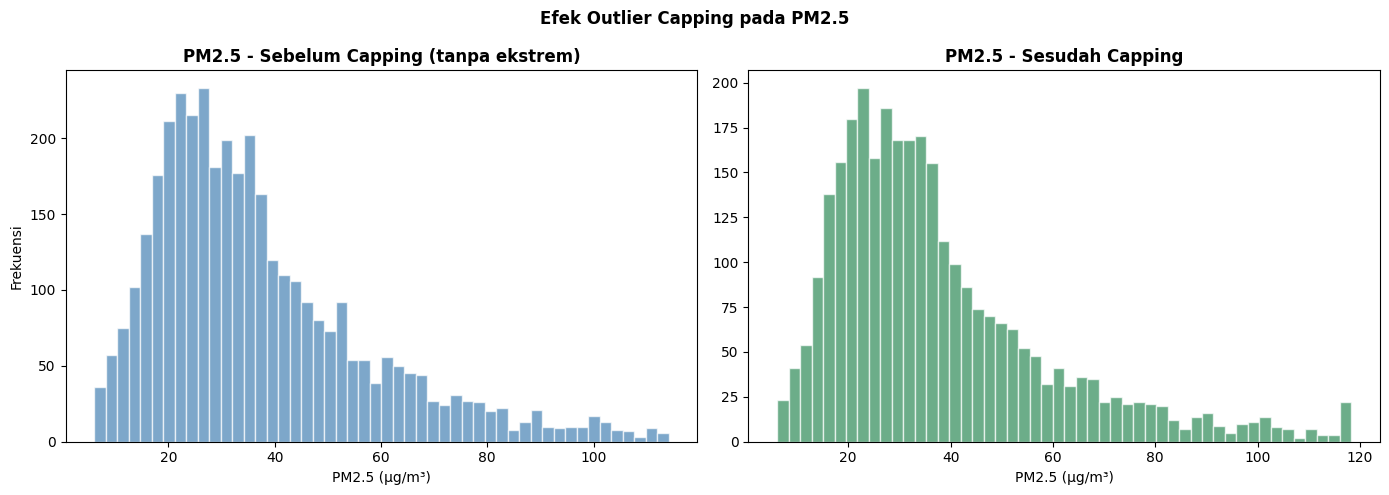

💾 Disimpan → reports/preprocessing/outlier_capping_pm25.png


In [5]:
# Visualisasi sebelum-sesudah capping (opsional)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data asli (sebelum capping)
original = pd.read_csv("data/raw/surabaya_airquality_raw.csv")
original_pm25 = original["pm25"].dropna()
original_pm25 = original_pm25[original_pm25 < original_pm25.quantile(0.99)]  # buang outlier ekstrem untuk visualisasi

# Data setelah capping
capped_pm25 = train_raw["pm25"]

axes[0].hist(original_pm25, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].set_title("PM2.5 - Sebelum Capping (tanpa ekstrem)", fontweight="bold")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(capped_pm25, bins=50, color="seagreen", alpha=0.7, edgecolor="white")
axes[1].set_title("PM2.5 - Sesudah Capping", fontweight="bold")
axes[1].set_xlabel("PM2.5 (µg/m³)")

plt.suptitle("Efek Outlier Capping pada PM2.5", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/preprocessing/outlier_capping_pm25.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/preprocessing/outlier_capping_pm25.png")

## 5. Feature Engineering
Semua fitur dibuat dari data gabungan train+test (urutan waktu)

In [6]:
train_raw["_split"] = "train"
test_raw["_split"] = "test"
df_fe = pd.concat([train_raw, test_raw], ignore_index=True).sort_values("time")

print(f"Shape gabungan: {df_fe.shape}")

Shape gabungan: (3768, 7)


### 5.1 Fitur Waktu & Segmentasi

In [7]:
df_fe["hour"] = df_fe["time"].dt.hour
df_fe["day_of_week"] = df_fe["time"].dt.dayofweek
df_fe["month"] = df_fe["time"].dt.month
df_fe["is_weekend"] = (df_fe["day_of_week"] >= 5).astype(int)

def assign_segment(hour):
    if 6 <= hour <= 11: return "PAGI"
    elif 12 <= hour <= 17: return "SIANG"
    else: return "SORE_MALAM"

df_fe["time_segment"] = df_fe["hour"].apply(assign_segment)

print("✅ Fitur waktu selesai")
print(df_fe["time_segment"].value_counts())

✅ Fitur waktu selesai
time_segment
SORE_MALAM    1884
PAGI           942
SIANG          942
Name: count, dtype: int64


### 5.2 Fitur Lag (1h, 3h, 24h)

In [8]:
LAG_WINDOWS = [1, 3, 24]
for pol in POLUTAN:
    for lag in LAG_WINDOWS:
        df_fe[f"{pol}_lag_{lag}h"] = df_fe[pol].shift(lag)

print("✅ Fitur lag selesai")

✅ Fitur lag selesai


### 5.3 Fitur Rolling (mean, std, max)

In [9]:
for pol in POLUTAN:
    df_fe[f"{pol}_rolling_mean_3h"] = df_fe[pol].rolling(3, min_periods=1).mean()
    df_fe[f"{pol}_rolling_mean_24h"] = df_fe[pol].rolling(24, min_periods=1).mean()
    df_fe[f"{pol}_rolling_std_24h"] = df_fe[pol].rolling(24, min_periods=1).std()
    df_fe[f"{pol}_rolling_max_24h"] = df_fe[pol].rolling(24, min_periods=1).max()

print("✅ Fitur rolling selesai")

✅ Fitur rolling selesai


### 5.4 Fitur Perubahan (diff, pct_change)

In [10]:
for pol in POLUTAN:
    df_fe[f"{pol}_diff_1h"] = df_fe[pol].diff(1)
    df_fe[f"{pol}_pct_change_1h"] = df_fe[pol].pct_change(1).replace([np.inf, -np.inf], np.nan)

print("✅ Fitur perubahan selesai")

✅ Fitur perubahan selesai


## 6. Buat Label `is_anomaly`

In [11]:
print("=" * 60)
print("5. BUAT LABEL is_anomaly")
print("=" * 60)

# Kriteria 1: PM2.5 > mean_24h + 2*std_24h (spike)
crit1 = df_fe["pm25"] > (df_fe["pm25_rolling_mean_24h"] + 2 * df_fe["pm25_rolling_std_24h"])

# Kriteria 2: PM10 > mean_24h + 2*std_24h
crit2 = df_fe["pm10"] > (df_fe["pm10_rolling_mean_24h"] + 2 * df_fe["pm10_rolling_std_24h"])

# Kriteria 3: CO > mean_24h + 2*std_24h
crit3 = df_fe["co"] > (df_fe["co_rolling_mean_24h"] + 2 * df_fe["co_rolling_std_24h"])

# Label anomali (1 jika salah satu kriteria terpenuhi)
df_fe["is_anomaly"] = (crit1 | crit2 | crit3).astype(int)

n_anomali = df_fe["is_anomaly"].sum()
n_normal = len(df_fe) - n_anomali
print(f"\nLabel is_anomaly:")
print(f"  0 = Normal : {n_normal:,} baris ({n_normal/len(df_fe)*100:.1f}%)")
print(f"  1 = Anomali: {n_anomali:,} baris ({n_anomali/len(df_fe)*100:.1f}%)")

5. BUAT LABEL is_anomaly

Label is_anomaly:
  0 = Normal : 3,374 baris (89.5%)
  1 = Anomali: 394 baris (10.5%)


## 7. Drop Baris Warmup (NaN akibat Lag 24h)

In [12]:
shape_before = df_fe.shape
critical_lag_cols = [f"{p}_lag_24h" for p in POLUTAN]
df_fe = df_fe.dropna(subset=critical_lag_cols).reset_index(drop=True)

pct_cols = [f"{p}_pct_change_1h" for p in POLUTAN]
df_fe[pct_cols] = df_fe[pct_cols].fillna(0)

diff_cols = [f"{p}_diff_1h" for p in POLUTAN]
df_fe[diff_cols] = df_fe[diff_cols].fillna(0)

print(f"Shape sebelum: {shape_before}")
print(f"Shape setelah : {df_fe.shape}")
print(f"Baris di-drop: {shape_before[0] - df_fe.shape[0]} (warmup lag 24h)")

Shape sebelum: (3768, 58)
Shape setelah : (3744, 58)
Baris di-drop: 24 (warmup lag 24h)


## 8. Encoding `time_segment`

In [13]:
segment_dummies = pd.get_dummies(df_fe["time_segment"], prefix="seg", drop_first=False)
df_fe = pd.concat([df_fe, segment_dummies], axis=1)

print("✅ One-Hot Encoding selesai")
print(f"Kolom baru: {list(segment_dummies.columns)}")

✅ One-Hot Encoding selesai
Kolom baru: ['seg_PAGI', 'seg_SIANG', 'seg_SORE_MALAM']


## 9. Pisahkan Kembali Train & Test, Lalu Scaling

In [14]:
train_fe = df_fe[df_fe["_split"] == "train"].copy().drop(columns=["_split"])
test_fe = df_fe[df_fe["_split"] == "test"].copy().drop(columns=["_split"])

print(f"Train shape: {train_fe.shape}")
print(f"Test shape : {test_fe.shape}")

Train shape: (2990, 60)
Test shape : (754, 60)


In [15]:
EXCLUDE_SCALE = [
    "time", "time_segment", "is_anomaly", "is_weekend",
    "seg_PAGI", "seg_SIANG", "seg_SORE_MALAM"
]

scale_cols = [c for c in train_fe.select_dtypes(include=[np.number]).columns if c not in EXCLUDE_SCALE]

scaler = StandardScaler()
train_scaled = train_fe.copy()
test_scaled = test_fe.copy()

train_scaled[scale_cols] = scaler.fit_transform(train_fe[scale_cols])
test_scaled[scale_cols] = scaler.transform(test_fe[scale_cols])

joblib.dump(scaler, "models/standard_scaler.pkl")

print(f"✅ Scaler disimpan ke models/standard_scaler.pkl")
print(f"   Jumlah kolom di-scale: {len(scale_cols)}")

✅ Scaler disimpan ke models/standard_scaler.pkl
   Jumlah kolom di-scale: 53


## 10. Simpan Output

In [16]:
train_fe.to_csv("data/processed/train.csv", index=False)
test_fe.to_csv("data/processed/test.csv", index=False)
train_scaled.to_csv("data/processed/train_scaled.csv", index=False)
test_scaled.to_csv("data/processed/test_scaled.csv", index=False)

print("✅ File tersimpan:")
print(f"   train.csv          : {train_fe.shape}")
print(f"   test.csv           : {test_fe.shape}")
print(f"   train_scaled.csv   : {train_scaled.shape}")
print(f"   test_scaled.csv    : {test_scaled.shape}")

✅ File tersimpan:
   train.csv          : (2990, 60)
   test.csv           : (754, 60)
   train_scaled.csv   : (2990, 60)
   test_scaled.csv    : (754, 60)


## 11. Verifikasi Akhir

In [17]:
print("=" * 60)
print("11. VERIFIKASI AKHIR")
print("=" * 60)

checks = [
    ("Train tidak ada NaN", train_fe.isnull().sum().sum() == 0),
    ("Test tidak ada NaN", test_fe.isnull().sum().sum() == 0),
    ("is_anomaly ada", "is_anomaly" in train_fe.columns),
    ("is_anomaly hanya 0/1", set(train_fe["is_anomaly"].unique()).issubset({0, 1})),
    ("scaler tersimpan", os.path.exists("models/standard_scaler.pkl")),
]

for nama, kondisi in checks:
    print(f"  {'✅' if kondisi else '❌'} {nama}")

print("\n🎉 Notebook 03 selesai! Siap lanjut ke Notebook 04.")

11. VERIFIKASI AKHIR
  ✅ Train tidak ada NaN
  ✅ Test tidak ada NaN
  ✅ is_anomaly ada
  ✅ is_anomaly hanya 0/1
  ✅ scaler tersimpan

🎉 Notebook 03 selesai! Siap lanjut ke Notebook 04.
